The second edition of *Think Complexity* is available from [Bookshop.org](https://bookshop.org/a/98697/9781492040200) and [Amazon](https://amzn.to/3wPN0SJ) (those are affiliate links). If you are enjoying the free, online version, consider [buying me a coffee](https://buymeacoffee.com/allendowney).

# Game of Life

In this chapter we consider two-dimensional cellular automatons, especially John Conway's Game of Life (GoL). Like some of the 1-D CAs in the previous chapter, GoL follows simple rules and produces surprisingly complicated behavior. And like Wolfram's Rule 110, GoL turns out to be universal; that is, it can compute any computable function, at least in theory.

Complex behavior in GoL raises issues in the philosophy of science, particularly related to scientific realism and instrumentalism. I discuss these issues and suggest additional reading.

At the end of the chapter, I demonstrate ways to implement GoL efficiently in Python.

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ThinkComplexity/blob/v3/soln/chap06.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/nb/utils.py')
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/nb/Cell2D.py')

In [4]:
from utils import savefig
# make a directory for figures
!mkdir -p figs

## Conway's GoL

One of the first cellular automatons to be studied, and probably the most popular of all time, is a 2-D CA called "The Game of Life", or GoL for short. It was developed by John H. Conway and popularized in 1970 in Martin Gardner's column in *Scientific American*. See <https://thinkcomplex.com/gol>.

The cells in GoL are arranged in a 2-D **grid**, that is, an array of rows and columns. Usually the grid is considered to be infinite, but in practice it is often "wrapped"; that is, the right edge is connected to the left, and the top edge to the bottom.

Each cell in the grid has two states — live and dead — and 8 neighbors — north, south, east, west, and the four diagonals. This set of neighbors is sometimes called a "Moore neighborhood".

Like the 1-D CAs in the previous chapters, GoL evolves over time according to rules, which are like simple laws of physics.

In GoL, the next state of each cell depends on its current state and its number of live neighbors. If a cell is alive, it stays alive if it has 2 or 3 neighbors, and dies otherwise. If a cell is dead, it stays dead unless it has exactly 3 neighbors.

This behavior is loosely analogous to real cell growth: cells that are isolated or overcrowded die; at moderate densities they flourish.

GoL is popular because:

-   There are simple initial conditions that yield surprisingly complex behavior.

-   There are many interesting stable patterns: some oscillate (with various periods) and some move like the spaceships in Wolfram's Rule 110 CA.

-   And like Rule 110, GoL is Turing complete.

-   Another factor that generated interest was Conway's conjecture — that there is no initial condition that yields unbounded growth in the number of live cells — and the \$50 bounty he offered to anyone who could prove or disprove it.

-   Finally, the increasing availability of computers made it possible to automate the computation and display the results graphically.

The following class implements GoL; it is based on `Cell2D`, which provides methods for initializing, drawing, and animating a 2-D CA. I'll explain how `step` works at the end of the chapter.

In [5]:
from scipy.signal import correlate2d
from Cell2D import Cell2D

class Life(Cell2D):
    """Implementation of Conway's Game of Life."""
    kernel = np.array([[1, 1, 1],
                       [1,10, 1],
                       [1, 1, 1]])

    table = np.zeros(20, dtype=np.uint8)
    table[[3, 12, 13]] = 1

    def step(self):
        """Executes one time step."""
        c = correlate2d(self.array, self.kernel, mode='same')
        self.array = self.table[c]

The following function creates a `Life` object and sets the initial condition using strings of `0` and `1` characters.

In [6]:
def make_life(n, m, row, col, *strings):
    """Makes a Life object.
    
    n, m: rows and columns of the Life array
    row, col: upper left coordinate of the cells to be added
    strings: list of strings of '0' and '1'
    """
    life = Life(n, m)
    life.add_cells(row, col, *strings)
    return life

## Life patterns

If you run GoL from a random starting state, a number of stable patterns are likely to appear. Over time, people have identified these patterns and given them names.

For example, the following figure shows a stable pattern called a "beehive", also called a "still life".

Saving figure to file figs/chap06-1


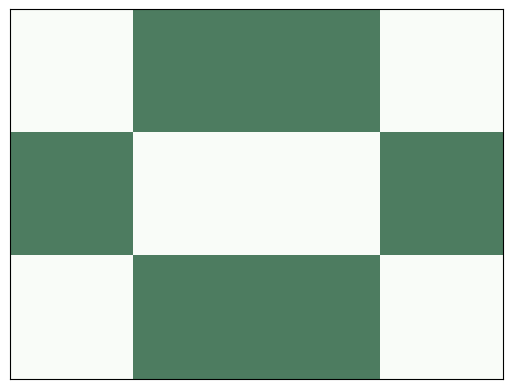

In [7]:
# beehive
life = make_life(3, 4, 0, 0, '0110', '1001', '0110')
life.draw()
savefig('figs/chap06-1')

Every cell in the beehive has 2 or 3 neighbors, so they all survive, and none of the dead cells adjacent to the beehive has 3 neighbors, so no new cells are born. Here's what it looks like after one step:

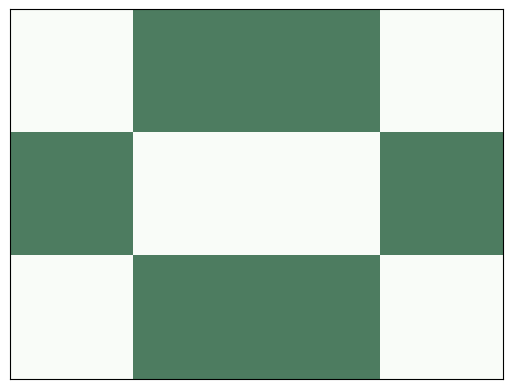

In [8]:
life.step()
life.draw()

Other patterns "oscillate"; that is, they change over time but eventually return to their starting configuration (provided they don't collide with another pattern). For example, the following figure shows a pattern called a "toad", which is an oscillator that alternates between two states. The "period" of this oscillator is 2.

Saving figure to file figs/chap06-2


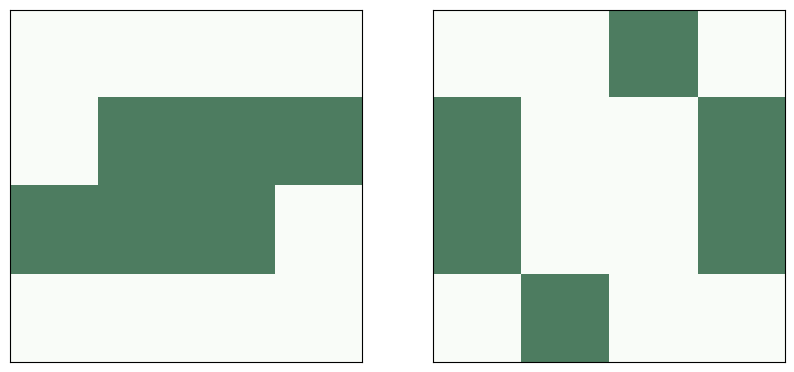

In [9]:
# toad
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
life = make_life(4, 4, 1, 0, '0111', '1110')
life.draw()

plt.subplot(1, 2, 2)
life.step()
life.draw()

savefig('figs/chap06-2')

Here's what the toad looks like as an animation.

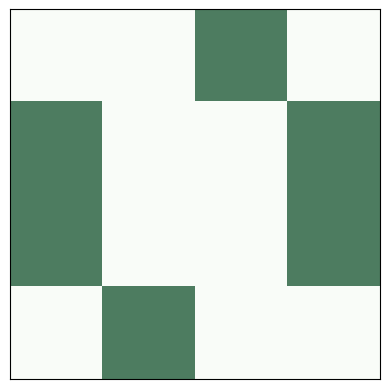

In [10]:
life = make_life(4, 4, 1, 0, '0111', '1110')
anim = life.animate(10, 0.5)

Finally, some patterns oscillate and return to the starting configuration, but shifted in space. Because these patterns seem to move, they are called "spaceships".

The following figure shows a spaceship called a "glider". After a period of 4 steps, the glider is back in the starting configuration, shifted one unit down and to the right.

In [11]:
# glider
plt.figure(figsize=(12, 4))

glider = ['010', '001', '111']
life = make_life(4, 4, 0, 0, *glider)

for i in range(1, 6):
    plt.subplot(1, 5, i)
    life.draw()
    life.step()
    
savefig('figs/chap06-3')

Saving figure to file figs/chap06-3


Here's an animation showing glider movement.

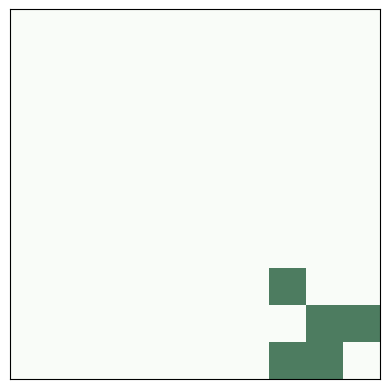

In [12]:
life = make_life(10, 10, 0, 0, '010', '001', '111')
life.animate(frames=28, interval=0.2)

Depending on the starting orientation, gliders can move along any of the four diagonals. There are other spaceships that move horizontally and vertically.

People have spent embarrassing amounts of time finding and naming these patterns. If you search the web, you will find many collections.

**Exercise:** If you start GoL from a random configuration, it usually runs chaotically for a while and then settles into stable patterns that include blinkers, blocks, and beehives, ships, boats, and loaves.

For a list of common "natually" occurring patterns, see Achim Flammenkamp, "[Most seen natural occurring ash objects in Game of Life](http://wwwhomes.uni-bielefeld.de/achim/freq_top_life.html)",

Start GoL in a random state and run it until it stabilizes (try 1000 steps).
What stable patterns can you identify?

Hint: use `np.random.randint`.

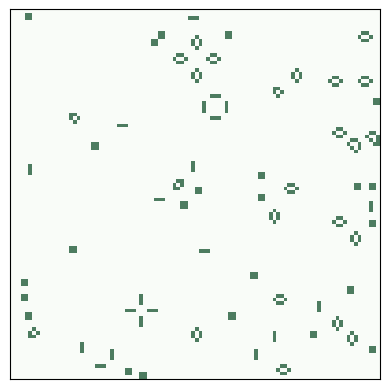

In [13]:
# Solution

n = 100
life = Life(n)
life.array = np.random.randint(2, size=(n, n), dtype=np.uint8)
life.animate(frames=1000)

## Conway's conjecture

From most initial conditions, GoL quickly reaches a stable state where the number of live cells is nearly constant (possibly with some oscillation).

But there are some simple starting conditions that yield a surprising number of live cells, and take a long time to settle down. Because these patterns are so long-lived, they are called "Methuselahs" (see <https://en.wikipedia.org/wiki/Methuselah_(cellular_automaton)>).

One of the simplest Methuselahs is the r-pentomino, which has only five cells, roughly in the shape of the letter "r".

In [14]:
# r pentomino
rpent = ['011', '110', '010']
life = make_life(3, 3, 0, 0, *rpent)
life.draw()

The following figure shows the initial configuration of the r-pentomino and the final configuration after 1103 steps.

In [15]:
# r pentomino
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
life = make_life(120, 120, 50, 45, *rpent)
life.draw()

for i in range(1103):
    life.step()

plt.subplot(1, 2, 2)
life.draw()

savefig('figs/chap06-4')

Saving figure to file figs/chap06-4


This configuration is "final" in the sense that all remaining patterns are either stable, oscillators, or gliders that will never collide with another pattern. In total, the r-pentomino yields 6 gliders, 8 blocks, 4 blinkers, 4 beehives, 1 boat, 1 ship, and 1 loaf.

And here's the animation that shows the steps.

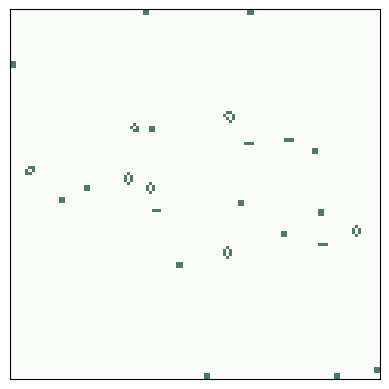

In [16]:
life = make_life(120, 120, 50, 45, *rpent)
life.animate(frames=1200)

The existence of long-lived patterns prompted Conway to wonder if there are initial patterns that never stabilize. He conjectured that there were not, but he described two kinds of pattern that would prove him wrong, a "gun" and a "puffer train". A gun is a stable pattern that periodically produces a spaceship — as the stream of spaceships moves out from the source, the number of live cells grows indefinitely. A puffer train is a translating pattern that leaves live cells in its wake (see <https://en.wikipedia.org/wiki/Puffer_train>).

It turns out that both of these patterns exist. A team led by Bill Gosper discovered the first, a glider gun now called Gosper's Gun, which produces a stream of gliders. Here is its initial configuration:

In [17]:
glider_gun = [
    '000000000000000000000000100000000000',
    '000000000000000000000010100000000000',
    '000000000000110000001100000000000011',
    '000000000001000100001100000000000011',
    '110000000010000010001100000000000000',
    '110000000010001011000010100000000000',
    '000000000010000010000000100000000000',
    '000000000001000100000000000000000000',
    '000000000000110000000000000000000000'
]

In [18]:
life = make_life(11, 38, 1, 1, *glider_gun)
life.draw()

savefig('figs/chap06-5')

Saving figure to file figs/chap06-5


And here's what it looks like running:

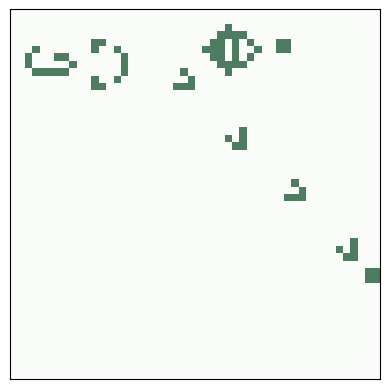

In [19]:
life = make_life(50, 50, 2, 2, *glider_gun)
life.animate(frames=200)

Gosper also discovered the first puffer train.

There are many patterns of both types, but they are not easy to design or find. That is not a coincidence. Conway chose the rules of GoL so that his conjecture would not be obviously true or false. Of all possible rules for a 2-D CA, most yield simple behavior: most initial conditions stabilize quickly or grow unboundedly. By avoiding uninteresting CAs, Conway was also avoiding Wolfram's Class 1 and Class 2 behavior, and probably Class 3 as well.

If we believe Wolfram's Principle of Computational Equivalence, we expect GoL to be in Class 4, and it is. The Game of Life was proved Turing complete in 1982 (and again, independently, in 1983). Since then, several people have constructed GoL patterns that implement a Turing machine or another machine known to be Turing complete.

## Realism

Stable patterns in GoL are hard not to notice, especially the ones that move. It is natural to think of them as persistent entities, but remember that a CA is made of cells; there is no such thing as a toad or a loaf. Gliders and other spaceships are even less real because they are not even made up of the same cells over time. So these patterns are like constellations of stars. We perceive them because we are good at seeing patterns, or because we have active imaginations, but they are not real.

Right?

Well, not so fast. Many entities that we consider "real" are also persistent patterns of entities at a smaller scale. Hurricanes are just patterns of air flow, but we give them personal names. And people, like gliders, are not made up of the same cells over time.

This is not a new observation — about 2500 years ago Heraclitus pointed out that you can't step in the same river twice — but the entities that appear in the Game of Life are a useful test case for thinking about scientific realism.

**Scientific realism** pertains to scientific theories and the entities they postulate. A theory postulates an entity if it is expressed in terms of the properties and behavior of the entity. For example, theories about electromagnetism are expressed in terms of electrical and magnetic fields. Some theories about economics are expressed in terms of supply, demand, and market forces. And theories about biology are expressed in terms of genes.

But are these entities real? That is, do they exist in the world independent of us and our theories?

Again, I find it useful to state philosophical positions in a range of strengths; here are four statements of scientific realism with increasing strength:

SR1:

:   Scientific theories are true or false to the degree that they approximate reality, but no theory is exactly true. Some postulated entities may be real, but there is no principled way to say which ones.

SR2:

:   As science advances, our theories become better approximations of reality. At least some postulated entities are known to be real.

SR3:

:   Some theories are exactly true; others are approximately true. Entities postulated by true theories, and some entities in approximate theories, are real.

SR4:

:   A theory is true if it describes reality correctly, and false otherwise. The entities postulated by true theories are real; others are not.

SR4 is so strong that it is probably untenable; by such a strict criterion, almost all current theories are known to be false. Most realists would accept something in the range between SR1 and SR3.

## Instrumentalism

But SR1 is so weak that it verges on **instrumentalism**, which is the view that theories are instruments that we use for our purposes: a theory is useful, or not, to the degree that it is fit for its purpose, but we can't say whether it is true or false.

To see whether you are comfortable with instrumentalism, I made up the following test. Read the following statements and give yourself a point for each one you agree with. If you score 4 or more, you might be an instrumentalist!

> "Entities in the Game of Life aren't real; they are just patterns of cells that people have given cute names."

> "A hurricane is just a pattern of air flow, but it is a useful description because it allows us to make predictions and communicate about the weather."

> "Freudian entities like the Id and the Superego aren't real, but they are useful tools for thinking and communicating about psychology (or at least some people think so)."

> "Electric and magnetic fields are postulated entities in our best theory of electromagnetism, but they aren't real. We could construct other theories, without postulating fields, that would be just as useful."

> "Many of the things in the world that we identify as objects are arbitrary collections like constellations. For example, a mushroom is just the fruiting body of a fungus, most of which grows underground as a barely-contiguous network of cells. We focus on mushrooms for practical reasons like visibility and edibility."

> "Some objects have sharp boundaries, but many are fuzzy. For example, which molecules are part of your body: Air in your lungs? Food in your stomach? Nutrients in your blood? Nutrients in a cell? Water in a cell? Structural parts of a cell? Hair? Dead skin? Dirt? Bacteria on your skin? Bacteria in your gut? Mitochondria? How many of those molecules do you include when you weigh yourself? Conceiving the world in terms of discrete objects is useful, but the entities we identify are not real."

If you are more comfortable with some of these statements than others, ask yourself why. What are the differences in these scenarios that influence your reaction? Can you make a principled distinction between them?

For more on instrumentalism, see <https://thinkcomplex.com/instr>.

## Implementing Life

The exercises at the end of this chapter ask you to experiment with and modify the Game of Life, and implement other 2-D cellular automatons. This section explains my implementation of GoL, which you can use as a starting place for your experiments.

To represent the state of the cells, I use a NumPy array of 8-bit unsigned integers. As an example, the following line creates a 10 by 10 array initialized with random values of 0 and 1.

In [20]:
a = np.random.randint(2, size=(10, 10), dtype=np.uint8)
print(a)

[[0 1 0 0 1 1 1 1 1 1]
 [0 1 0 1 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [1 0 0 1 1 1 1 1 1 1]
 [1 0 1 0 0 0 0 0 0 1]
 [1 1 0 1 1 1 1 1 0 0]
 [1 1 1 0 0 1 1 1 0 0]
 [1 0 1 1 0 0 1 0 0 1]
 [1 1 0 1 0 1 1 0 0 1]
 [1 1 0 0 0 1 1 1 1 0]]


There are a few ways we can compute the GoL rules. The simplest is to use `for` loops to iterate through the rows and columns of the array:

In [21]:
b = np.zeros_like(a)
rows, cols = a.shape
for i in range(rows):
    for j in range(cols):
        state = a[i, j]
        neighbors = a[max(i-1, 0):i+2, max(j-1, 0):j+2]
        k = np.sum(neighbors) - state
        if state:
            if k==2 or k==3:
                b[i, j] = 1
        else:
            if k == 3:
                b[i, j] = 1

print(b)

[[0 0 1 1 0 0 0 0 1 0]
 [0 0 1 1 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 1]
 [0 1 0 1 1 1 1 1 0 1]
 [1 0 1 0 0 0 0 0 0 1]
 [0 0 0 1 1 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 0 1]
 [1 1 1 0 1 1 0 1 1 0]]


Initially, `b` is an array of zeros with the same size as `a`. Each time through the loop, `state` is the condition of the center cell and `neighbors` is the 3x3 neighborhood (smaller at the edges of the array, where some neighbors are missing). `k` is the number of live neighbors (not including the center cell). The nested `if` statements evaluate the GoL rules and turn on cells in `b` accordingly.

This implementation is a straightforward translation of the rules, but it is verbose and slow. We can do better using cross-correlation, as we saw in Chapter 5. There, we used `np.correlate` to compute a 1-D correlation. Now, to perform 2-D correlation, we'll use `correlate2d` from `scipy.signal`, a SciPy module that provides functions related to signal processing:

In [22]:
from scipy.signal import correlate2d

kernel = np.array([[1, 1, 1],
                   [1, 0, 1],
                   [1, 1, 1]])

c = correlate2d(a, kernel, mode='same')

What we called a "window" in the context of 1-D correlation is called a "kernel" in the context of 2-D correlation, but the idea is the same: `correlate2d` multiplies the kernel and the array to select a neighborhood, then adds up the result. This kernel selects the 8 neighbors that surround the center cell.

`correlate2d` applies the kernel to each location in the array. With `mode='same'`, the result has the same size as `a`.

Now we can use logical operators to compute the rules:

In [23]:
b = (c==3) | (c==2) & a
b = b.astype(np.uint8)
print(b)

[[0 0 1 1 0 0 0 0 1 0]
 [0 0 1 1 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 1]
 [0 1 0 1 1 1 1 1 0 1]
 [1 0 1 0 0 0 0 0 0 1]
 [0 0 0 1 1 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 0 1]
 [1 1 1 0 1 1 0 1 1 0]]


The first line computes a boolean array with `True` where there should be a live cell and `False` elsewhere. Then `astype` converts the boolean array to an array of integers.

This version is faster, and probably good enough, but we can simplify it slightly by modifying the kernel:

In [24]:
kernel = np.array([[1, 1, 1],
                   [1,10, 1],
                   [1, 1, 1]])

c = correlate2d(a, kernel, mode='same')
b = (c==3) | (c==12) | (c==13)
b = b.astype(np.uint8)
print(b)

[[0 0 1 1 0 0 0 0 1 0]
 [0 0 1 1 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 1]
 [0 1 0 1 1 1 1 1 0 1]
 [1 0 1 0 0 0 0 0 0 1]
 [0 0 0 1 1 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 0 1]
 [1 1 1 0 1 1 0 1 1 0]]


This version of the kernel includes the center cell and gives it a weight of 10. If the center cell is 0, the result is between 0 and 8; if the center cell is 1, the result is between 10 and 18. Using this kernel, we can simplify the logical operations, selecting only cells with the values 3, 12, and 13.

That might not seem like a big improvement, but it allows one more simplification: with this kernel, we can use a table to look up cell values, as we did in Chapter 5.

In [25]:
table = np.zeros(20, dtype=np.uint8)
table[[3, 12, 13]] = 1
c = correlate2d(a, kernel, mode='same')
b = table[c]
print(b)

[[0 0 1 1 0 0 0 0 1 0]
 [0 0 1 1 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 1]
 [0 1 0 1 1 1 1 1 0 1]
 [1 0 1 0 0 0 0 0 0 1]
 [0 0 0 1 1 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 0 1]
 [1 1 1 0 1 1 0 1 1 0]]


`table` has zeros everywhere except locations 3, 12, and 13. When we use `c` as an index into `table`, NumPy performs element-wise lookup; that is, it takes each value from `c`, looks it up in `table`, and puts the result into `b`.

This version is faster and more concise than the others; the only drawback is that it takes more explaining.

The `Life` class at the beginning of this chapter encapsulates this implementation of the rules.

## Exercises

**Exercise:** Many Game of Life patterns are available in portable file formats.  For one source, see http://www.conwaylife.com/wiki/Main_Page.

Write a function to parse one of these formats and initialize the array.

In [26]:
# Solution

# The easiest format to parse is plain text: 
        
def read_life_file(life, filename, row, col):
    i = row
    with open(filename) as f:
        for line in f:
            if line.startswith('!'):
                continue
            line = line.strip()
            line = line.replace('O', '1')
            line = line.replace('.', '0')
            life.add_cells(i, col, line)
            i += 1

In [27]:
# Solution

download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/data/35p52.cells.txt')

In [28]:
# Solution

# Here's an example that loads a period 52 oscillator.

n = 19
m = 19
row = 1
col = 1

life = Life(n, m)
filename = '35p52.cells.txt'
read_life_file(life, filename, row, col)
life.draw()

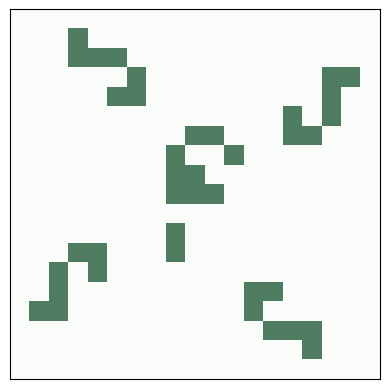

In [29]:
# Solution

# And here's the animation

life.animate(frames=52, interval=0.1)

**Exercise:** One of the longest-lived small patterns is "rabbits", which starts with 9 live cells and takes 17,331 steps to stabilize. You can get the initial configuration in various formats from <https://thinkcomplex.com/rabbits>. Load this configuration and run it.

**Exercise:** One variation of GoL, called "Highlife", has the same rules as GoL, plus one additional rule: a dead cell with 6 neighbors comes to life.

You can try out different rules by inheriting from `Life` and changing the lookup table. Modify the table below to add the new rule.

In [30]:
# Starter code

class MyLife(Life):
    """Implementation of Life."""

    table = np.zeros(20, dtype=np.uint8)
    table[[3, 12, 13]] = 1

One of the more interesting patterns in Highlife is the replicator (see <https://thinkcomplex.com/repl>), which has the following initial configuration.

In [31]:
replicator = [
    '00111',
    '01001',
    '10001',
    '10010',
    '11100'
]

Make a `MyLife` object with `n=100` and use `add_cells` to put a replicator near the middle.

Make an animation with about 200 frames and see how it behaves.

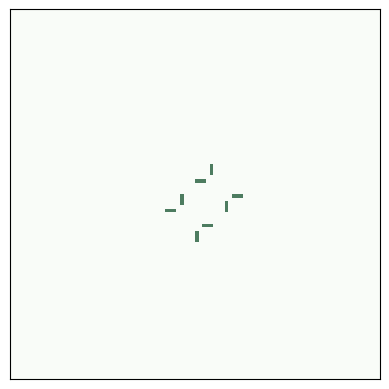

In [32]:
# Solution

n = 100
life = MyLife(n)
life.add_cells(n//2, n//2, *replicator)
life.animate(frames=200)

**Exercise:** If you generalize the Turing machine to two dimensions, or add a read-write head to a 2-D CA, the result is a cellular automaton called a Turmite. It is named after a termite because of the way the read-write head moves, but spelled wrong as an homage to Alan Turing.

The most famous Turmite is Langton's Ant, discovered by Chris Langton in 1986. See <https://thinkcomplex.com/langton>.

The ant is a read-write head with four states, which you can think of as facing north, south, east or west. The cells have two states, black and white.

The rules are simple. During each time step, the ant checks the color of the cell it is on. If black, the ant turns to the right, changes the cell to white, and moves forward one space. If the cell is white, the ant turns left, changes the cell to black, and moves forward.

Given a simple world, a simple set of rules, and only one moving part, you might expect to see simple behavior — but you should know better by now. Starting with all white cells, Langton's ant moves in a seemingly random pattern for more than 10,000 steps before it enters a cycle with a period of 104 steps. After each cycle, the ant is translated diagonally, so it leaves a trail called the "highway".

Write an implementation of Langton's Ant.

In [33]:
# Solution

from matplotlib.patches import RegularPolygon

class Turmite(Cell2D):
    """Implements Langton's Ant"""

    # map from orientation to (di, dj)
    move = {0: (-1, 0),  # north
            1: (0, 1),   # east
            2: (1, 0),   # south
            3: (0, -1)}  # west

    def __init__(self, n, m=None):
        """Initializes the attributes.

        n: number of rows
        m: number of columns
        """
        m = n if m is None else m
        self.array = np.zeros((n, m), np.uint8)
        self.loc = np.array([n//2, m//2])
        self.state = 0

    def step(self):
        """Executes one time step."""
        # in order to use an array as an index, we have to make it a tuple
        # https://docs.scipy.org/doc/numpy/user/quickstart.html#indexing-with-arrays-of-indices
        loc = tuple(self.loc)

        # get the state of the current cell
        try:
            cell = self.array[loc]
        except IndexError:
            raise IndexError('The turmite has gone off the grid')

        # toggle the current cell
        self.array[loc] ^= 1

        if cell:
            # turn left
            self.state = (self.state + 3) % 4
        else:
            # turn right
            self.state = (self.state + 1) % 4

        move = self.move[self.state]
        self.loc += move

    def draw(self):
        """Updates the display with the state of the grid."""
        super().draw()
        
        # draw the arrow
        center, orientation = self.arrow_specs()
        self.arrow = RegularPolygon(center, 3, color='orange',
                                    radius=0.4, orientation=orientation)
        ax = plt.gca()
        ax.add_patch(self.arrow)

    def arrow_specs(self):
        """Computes the center and orientation of the arrow."""
        a = self.array
        n, m = a.shape
        i, j = self.loc
        center = j+0.5, n-i-0.5
        orientation = -np.pi / 2 * self.state
        return center, orientation

In [34]:
n = 5
turmite = Turmite(n)
turmite.draw()

In [35]:
turmite.step()
turmite.draw()

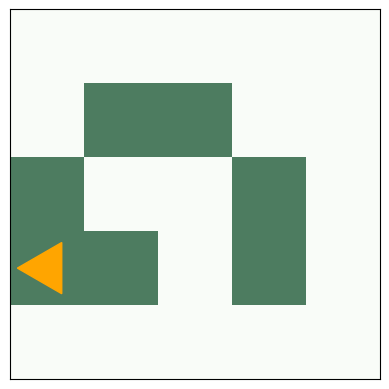

In [36]:
# Solution

# Here's a small version that shows the first 20 steps:

turmite = Turmite(n=5)
anim = turmite.animate(frames=20, interval=0.5)

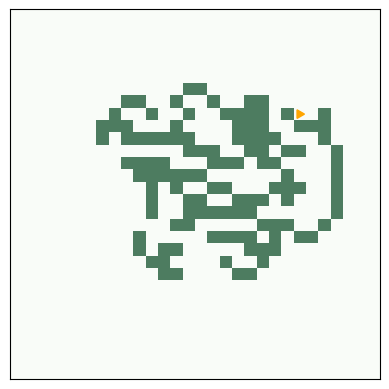

In [37]:
# And a larger version with 1000 steps

turmite = Turmite(n=30)
turmite.animate(frames=1000)

[Think Complexity, 2nd Edition](https://greenteapress.com/wp/think-complexity-2e/)

Copyright 2016 [Allen B. Downey](https://allendowney.com)

Code license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)